In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [2]:
dataset = pd.read_csv('dataset.csv')

In [3]:
# Tiền xử lý dữ liệu

# Làm sạch dữ liệu

# Xóa 2 cột NULL htmlDescription và image
dataset.isnull()
dataset = dataset.drop(columns=['htmlDescription', 'image'], errors='ignore')

# Thay thế các dòng NULL = bỏ trống của cột salesRepEmployeeNumber và postalCode
if "salesRepEmployeeNumber" in dataset.columns:
    dataset["salesRepEmployeeNumber"] = dataset["salesRepEmployeeNumber"].fillna("")

if "postalCode" in dataset.columns:
    dataset["postalCode"] = dataset["postalCode"].fillna("")

# Lọc chỉ giữ các dòng có trạng thái 'Shipped'
dataset = dataset[dataset['status'] == 'Shipped']

In [4]:
# Định dạng kiểu số cho 4 cột priceEach, buyPrice, MSRP, quantityInStock
dataset[['priceEach', 'buyPrice', 'MSRP']].dtypes
dataset['buyPrice'] = pd.to_numeric(dataset['buyPrice'], errors='coerce')
dataset[['priceEach', 'buyPrice', 'MSRP']].dtypes
dataset[['quantityInStock']].dtypes
dataset['quantityInStock'] = pd.to_numeric(dataset['quantityInStock'], errors='coerce')
dataset[['quantityInStock']].dtypes

# Kiểm tra Missing Values
dataset[['priceEach', 'buyPrice', 'MSRP']].isnull().sum()
dataset.dropna(subset=['buyPrice'], inplace=True) # Loại bỏ các dóng có giá trị NULL của cột buyPrice
dataset[['priceEach', 'buyPrice', 'MSRP']].isnull().sum()

dataset[['productLine', 'country', 'quantityInStock', 'quantityOrdered']].isnull().sum()

median_stock = dataset['quantityInStock'].median()
dataset['quantityInStock'] = dataset['quantityInStock'].fillna(median_stock)

In [5]:
# Kiểm tra Outliers
Q1 = dataset['MSRP'].quantile(0.25)
Q3 = dataset['MSRP'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['MSRP'] > upper_bound]
outliers_low = dataset[dataset['MSRP'] < lower_bound]

dataset['MSRP'] = np.where(dataset['MSRP'] > upper_bound, upper_bound, dataset['MSRP'])

In [6]:
Q1 = dataset['buyPrice'].quantile(0.25)
Q3 = dataset['buyPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['buyPrice'] > upper_bound]
outliers_low = dataset[dataset['buyPrice'] < lower_bound]

dataset['buyPrice'] = np.where(dataset['buyPrice'] > upper_bound, upper_bound, dataset['buyPrice'])

In [7]:
Q1 = dataset['priceEach'].quantile(0.25)
Q3 = dataset['priceEach'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['priceEach'] > upper_bound]
outliers_low = dataset[dataset['priceEach'] < lower_bound]

dataset['priceEach'] = np.where(dataset['priceEach'] > upper_bound, upper_bound, dataset['priceEach'])

In [8]:
Q1 = dataset['quantityOrdered'].quantile(0.25)
Q3 = dataset['quantityOrdered'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['quantityOrdered'] > upper_bound]
outliers_low = dataset[dataset['quantityOrdered'] < lower_bound]

In [9]:
Q1 = dataset['quantityInStock'].quantile(0.25)
Q3 = dataset['quantityInStock'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['quantityInStock'] > upper_bound]
outliers_low = dataset[dataset['quantityInStock'] < lower_bound]

In [10]:
# Tạo các biến mới
dataset['revenue'] = dataset['priceEach'] * dataset['quantityOrdered']
dataset['profit'] = (dataset['priceEach'] - dataset['buyPrice']) * dataset['quantityOrdered']
dataset['profitMargin'] = dataset['profit'] / dataset['revenue']

dataset['orderDate'] = pd.to_datetime(dataset['orderDate'])
dataset['orderYear'] = dataset['orderDate'].dt.year
dataset['orderQuarter'] = dataset['orderDate'].dt.quarter
dataset['orderMonth'] = dataset['orderDate'].dt.month
dataset['orderDayOfWeek'] = dataset['orderDate'].dt.dayofweek

dataset['discountRate'] = (dataset['MSRP'] - dataset['priceEach']) / dataset['MSRP']

avg_margin = dataset['profitMargin'].mean()
dataset['isHighMargin'] = dataset['profitMargin'] > avg_margin

dataset['orderValue'] = dataset.groupby('orderNumber')['revenue'].transform('sum')
dataset['customerLifeTimeValue'] = dataset.groupby('customerNumber')['revenue'].transform('sum')
dataset['customerSegment'] = pd.qcut(
    dataset['customerLifeTimeValue'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [11]:
# Chuẩn hóa và Mã hóa dữ liệu
minmax_scaler = MinMaxScaler()
minmax_vars = ['revenue', 'profit', 'orderValue', 'quantityOrdered', 'customerLifeTimeValue',
               'creditLimit', 'buyPrice', 'MSRP', 'quantityInStock', 'discountRate', 'profitMargin', 'priceEach']
dataset[minmax_vars] = minmax_scaler.fit_transform(dataset[minmax_vars])

segment_mapping = {'Low Value': 0, 'Medium Value': 1, 'High Value': 2}
dataset['customerSegment_encoded'] = dataset['customerSegment'].map(segment_mapping)

def cyclical_encode(series, period):
    sin_encoded = np.sin(2 * np.pi * series / period)
    cos_encoded = np.cos(2 * np.pi * series / period)
    return sin_encoded, cos_encoded

dataset['month_sin'], dataset['month_cos'] = cyclical_encode(dataset['orderMonth'], 12)
dataset['quarter_sin'], dataset['quarter_cos'] = cyclical_encode(dataset['orderQuarter'], 4)

dataset = pd.get_dummies(dataset, columns=['productLine', 'country'], prefix=['product', 'country'])


In [12]:
Q1 = dataset['profit'].quantile(0.25)
Q3 = dataset['profit'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['profit'] > upper_bound]
outliers_low = dataset[dataset['profit'] < lower_bound]

dataset['profit'] = np.where(dataset['profit'] < lower_bound, lower_bound, dataset['profit'])

In [13]:
Q1 = dataset['profitMargin'].quantile(0.25)
Q3 = dataset['profitMargin'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['profitMargin'] > upper_bound]
outliers_low = dataset[dataset['profitMargin'] < lower_bound]

dataset['profitMargin'] = np.where(dataset['profitMargin'] < lower_bound, lower_bound, dataset['profitMargin'])

In [14]:
Q1 = dataset['discountRate'].quantile(0.25)
Q3 = dataset['discountRate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['discountRate'] > upper_bound]
outliers_low = dataset[dataset['discountRate'] < lower_bound]

dataset['discountRate'] = np.where(dataset['discountRate'] < lower_bound, lower_bound, dataset['discountRate'])

In [15]:
Q1 = dataset['customerLifeTimeValue'].quantile(0.25)
Q3 = dataset['customerLifeTimeValue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_high = dataset[dataset['customerLifeTimeValue'] > upper_bound]
outliers_low = dataset[dataset['customerLifeTimeValue'] < lower_bound]

In [111]:
# DANH SÁCH CÁC CỘT QUAN TRỌNG
country_columns = [col for col in dataset.columns if col.startswith('country_')]
product_columns = [col for col in dataset.columns if col.startswith('product_')]

ohe_colums = country_columns + product_columns
dataset[ohe_colums] = dataset[ohe_colums].astype(int)
columns = [
    'revenue', 'profit', 'profitMargin', 'orderValue', 
    'customerLifeTimeValue', 'creditLimit', 'priceEach', 'customerNumber', 'orderNumber',

    'buyPrice', 'MSRP', 'quantityOrdered', 'quantityInStock',
    'discountRate', 'isHighMargin',
    
    'orderYear', 'orderQuarter', 'orderMonth',
    'month_sin', 'month_cos',  
    
    'customerSegment_encoded', 'productScale', 'productVendor','orderDayOfWeek' 
]
all_colums = columns + ohe_colums
df = dataset[all_colums]

df

,revenue,profit,profitMargin,orderValue,customerLifeTimeValue,creditLimit,priceEach,customerNumber,orderNumber,buyPrice,...,country_Sweden,country_UK,country_USA,product_Classic Cars,product_Motorcycles,product_Planes,product_Ships,product_Trains,product_Trucks and Buses,product_Vintage Cars
0,0.211293,0.509966,0.910603,0.341073,0.112459,0.479686,0.323417,131,10107,0.305762,...,0,0,1,0,1,0,0,0,0,0
1,0.266633,0.546201,0.925482,0.250954,0.159380,0.323638,0.352152,353,10121,0.305762,...,0,0,0,0,1,0,0,0,0,0
2,0.357291,0.602858,0.938822,0.359233,0.118807,0.263620,0.380947,250,10134,0.305762,...,0,0,0,0,1,0,0,0,0,0
3,0.325247,0.543709,0.893830,0.793113,0.292354,0.367959,0.294622,205,10145,0.305762,...,0,0,1,0,1,0,0,0,0,0
4,0.386602,0.586510,0.910603,0.863053,0.468906,0.433980,0.323417,321,10159,0.305762,...,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,0.142212,0.455063,0.861849,0.810410,0.906038,0.921053,0.116683,124,10142,0.161617,...,0,0,1,0,0,0,1,0,0,0
986,0.228646,0.504060,0.891842,0.616650,1.000000,1.000000,0.146199,141,10153,0.161617,...,0,0,0,0,0,0,1,0,0,0
988,0.174760,0.486467,0.897745,0.455123,0.152331,0.224377,0.152751,344,10177,0.161617,...,0,0,0,0,0,0,1,0,0,0
989,0.085338,0.438332,0.865451,0.711623,0.460977,0.385503,0.119929,320,10185,0.161617,...,0,0,1,0,0,0,1,0,0,0


In [17]:
quantitative_vars = [
    'revenue', 'profit', 'orderValue', 
    'customerLifeTimeValue', 
    'buyPrice', 'MSRP', 
    'quantityOrdered', 'quantityInStock',
    'profitMargin', 'discountRate'
]

descriptive_stats = df[quantitative_vars].describe()
descriptive_stats

,revenue,profit,orderValue,customerLifeTimeValue,buyPrice,MSRP,quantityOrdered,quantityInStock,profitMargin,discountRate
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,0.289366,0.539536,0.585946,0.380753,0.371784,0.383758,0.485579,0.505509,0.905006,0.923880
std,0.175654,0.097910,0.220031,0.266620,0.221762,0.231471,0.302619,0.296186,0.049329,0.048731
min,0.000000,0.319674,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.763389,0.773955
25%,0.158154,0.476419,0.460718,0.174943,0.170074,0.203379,0.233333,0.236726,0.872148,0.886940
50%,0.254257,0.519801,0.589753,0.277534,0.357714,0.368657,0.466667,0.532458,0.909579,0.924613
75%,0.386244,0.580916,0.793113,0.490651,0.502045,0.522028,0.766667,0.772190,0.944655,0.962264
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


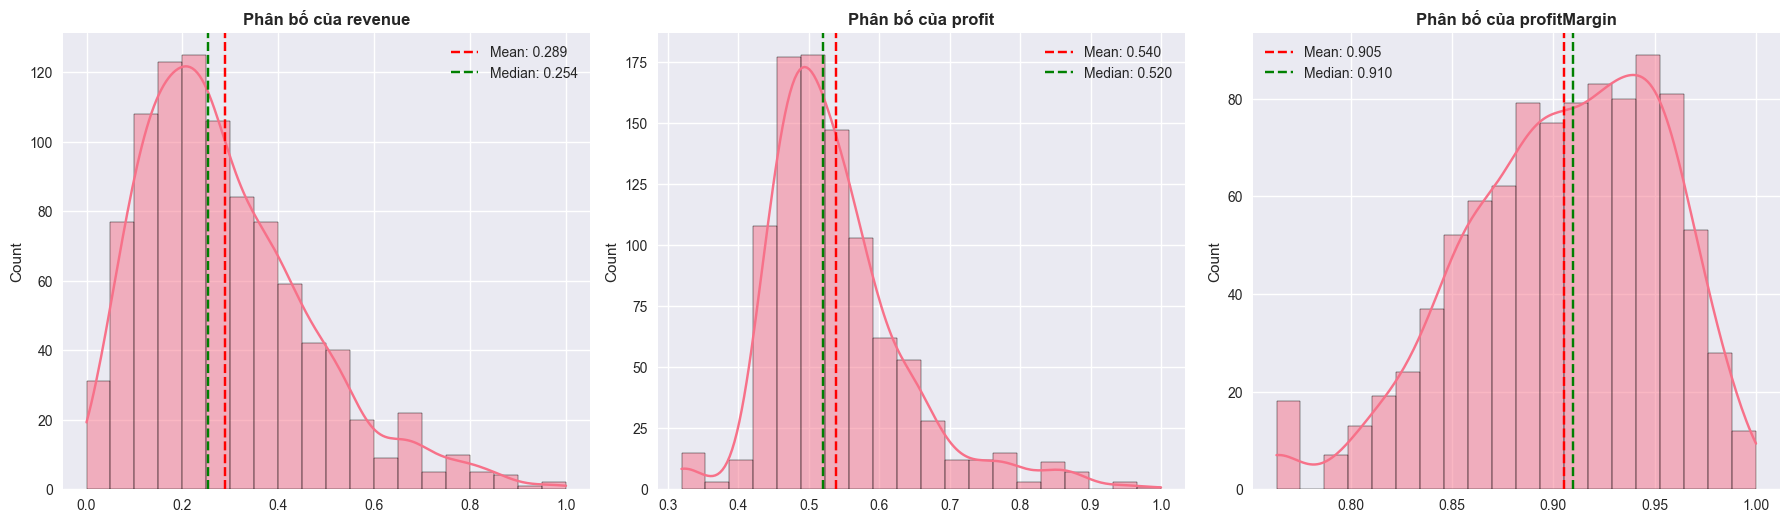

In [18]:
# 3.2. Quan sát phân bố và tương quan giữa các biến quan trọng 
# Thiết lập style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. PHÂN TÍCH PHÂN BỐ CÁC BIẾN QUAN TRỌNG

key_variables = ['revenue', 'profit', 'profitMargin']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for i, var in enumerate(key_variables):
    if i < len(axes):
        sns.histplot(data=df, x=var, ax=axes[i], kde=True, bins=20)
        axes[i].set_title(f'Phân bố của {var}', fontweight='bold')
        axes[i].set_xlabel('')
        
        mean_val = df[var].mean()
        median_val = df[var].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
        axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.3f}')
        axes[i].legend()

for i in range(len(key_variables), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


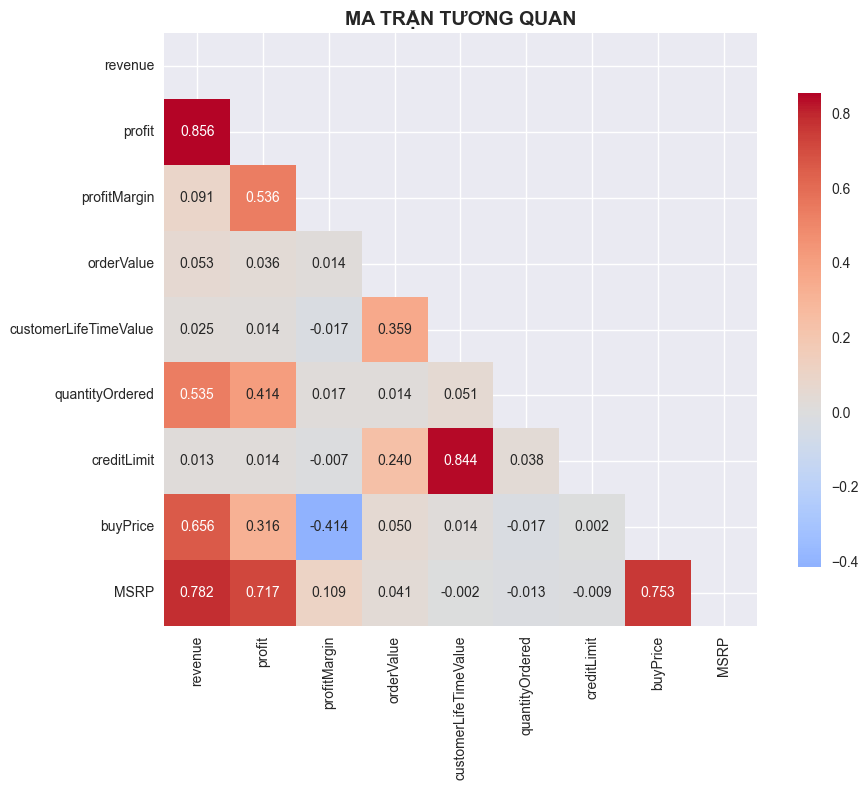

In [19]:
# 2. MA TRẬN TƯƠNG QUAN
# Chọn các biến số cho correlation matrix
corr_vars = ['revenue', 'profit', 'profitMargin', 'orderValue', 
             'customerLifeTimeValue', 'quantityOrdered', 'creditLimit',
             'buyPrice', 'MSRP']

# Tính correlation matrix
corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={"shrink": .8})
plt.title('MA TRẬN TƯƠNG QUAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

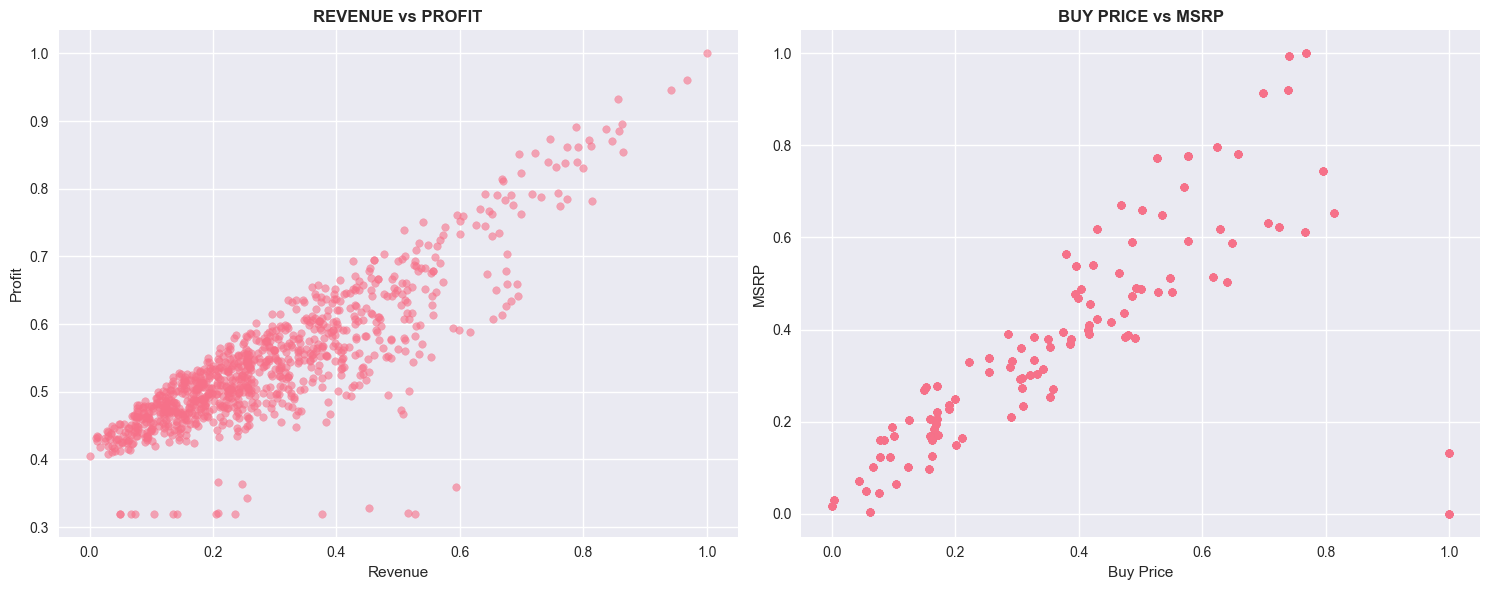

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) 

# 1. Biểu đồ 1: Revenue vs Profit
axes[0].scatter(df['revenue'], df['profit'], alpha=0.6, s=30)
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Profit')
axes[0].set_title(f"REVENUE vs PROFIT", fontweight='bold')

# 2. Biểu đồ 2: BuyPrice vs MSRP
axes[1].scatter(df['buyPrice'], df['MSRP'], alpha=0.6, s=30)
axes[1].set_xlabel('Buy Price')
axes[1].set_ylabel('MSRP')
axes[1].set_title(f"BUY PRICE vs MSRP", fontweight='bold')

plt.tight_layout()
plt.show()

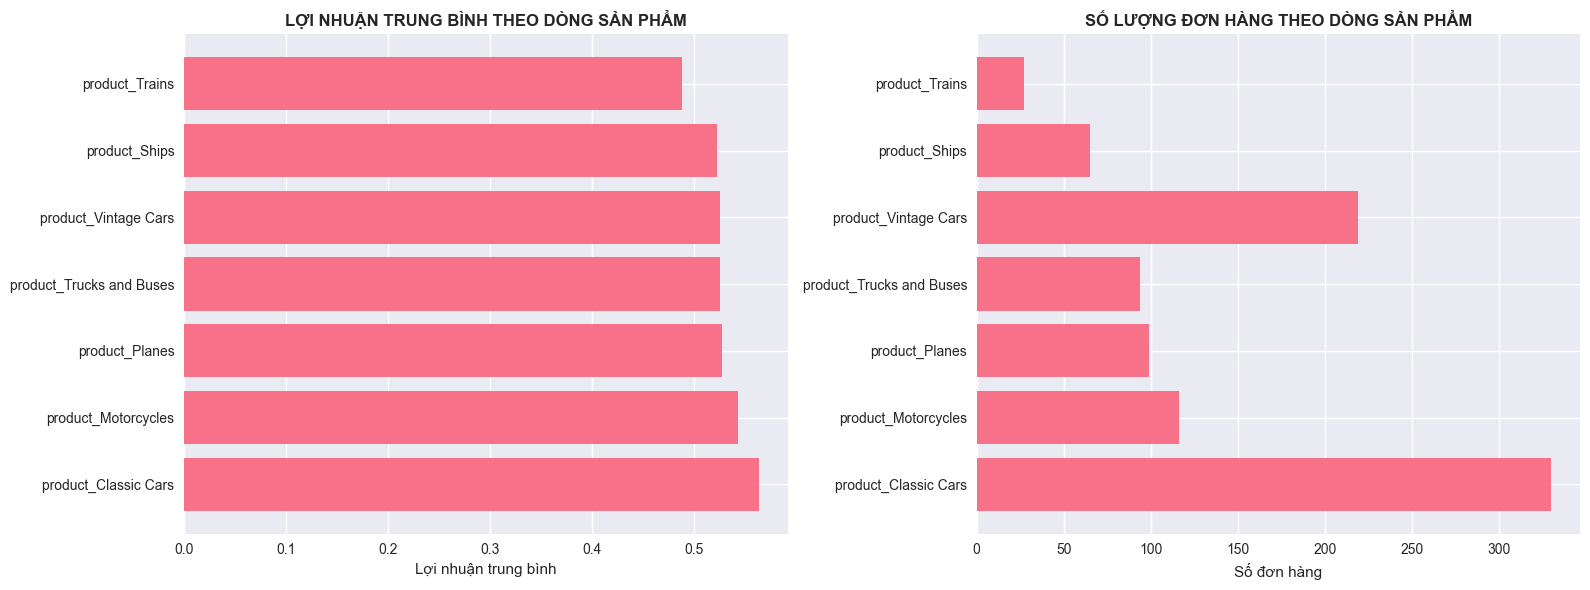

In [21]:
# 4. PHÂN TÍCH THEO PRODUCT LINE
product_cols = [col for col in df.columns if col.startswith('product_')]

product_analysis = pd.DataFrame()
for product in product_cols:
    product_data = df[df[product] == 1]
    product_analysis[product] = {
        'avg_revenue': product_data['revenue'].mean(),
        'avg_profit': product_data['profit'].mean(),
        'avg_profitMargin': product_data['profitMargin'].mean(),
        'order_count': len(product_data)
    }

product_analysis = product_analysis.T.sort_values('avg_profit', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(product_analysis.index, product_analysis['avg_profit'])
axes[0].set_title('LỢI NHUẬN TRUNG BÌNH THEO DÒNG SẢN PHẨM', fontweight='bold')
axes[0].set_xlabel('Lợi nhuận trung bình')

axes[1].barh(product_analysis.index, product_analysis['order_count'])
axes[1].set_title('SỐ LƯỢNG ĐƠN HÀNG THEO DÒNG SẢN PHẨM', fontweight='bold')
axes[1].set_xlabel('Số đơn hàng')

plt.tight_layout()
plt.show()

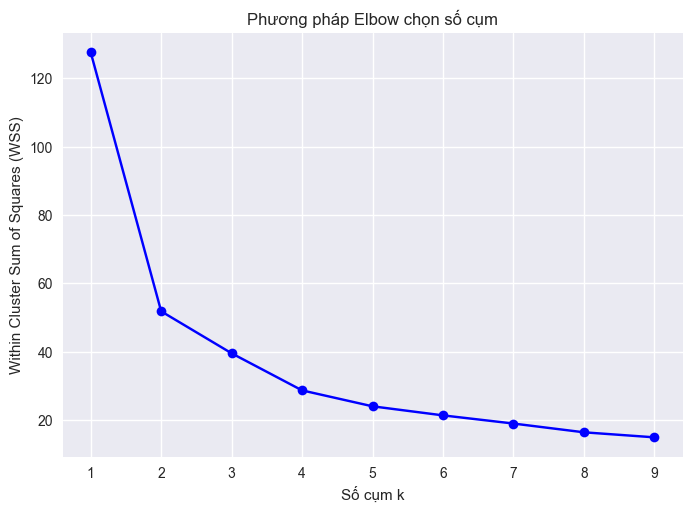

In [60]:
# 4.1. Mục tiêu #1: Xác định nhóm sản phẩm và thị trường trọng điểm theo doanh thu và lợi nhuận.

from sklearn.cluster import KMeans
features = ['revenue', 'profit', 'quantityOrdered', 'profitMargin']

test = df[features]
inertia = []
for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(test)
    inertia.append(model.inertia_)

plt.plot(range(1,10), inertia, 'bo-')
plt.xlabel('Số cụm k')
plt.ylabel('Within Cluster Sum of Squares (WSS)')
plt.title('Phương pháp Elbow chọn số cụm')
plt.show()

In [95]:
# Huấn luyện mô hình
kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[:, 'productCluster'] = kmeans.fit_predict(test)

In [96]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns= features)
centroids

,revenue,profit,quantityOrdered,profitMargin
0,0.592332,0.691813,0.783878,0.917881
1,0.283139,0.526879,0.737487,0.899805
2,0.197621,0.499584,0.228375,0.904299


In [97]:
cluster_names = {
    0: 'Sản phẩm xuất sắc',
    1: 'Sản phẩm ổn định', 
    2: 'Sản phẩm đặc thù'
}
df.loc[:,'cluster_name'] = df['productCluster'].map(cluster_names)

In [98]:
cluster_dist = df['cluster_name'].value_counts()
for cluster, count in cluster_dist.items():
    percentage = (count / len(df)) * 100
    print(f"   {cluster}: {count} sản phẩm ({percentage:.1f}%)")

   Sản phẩm đặc thù: 484 sản phẩm (50.9%)
   Sản phẩm ổn định: 312 sản phẩm (32.8%)
   Sản phẩm xuất sắc: 154 sản phẩm (16.2%)


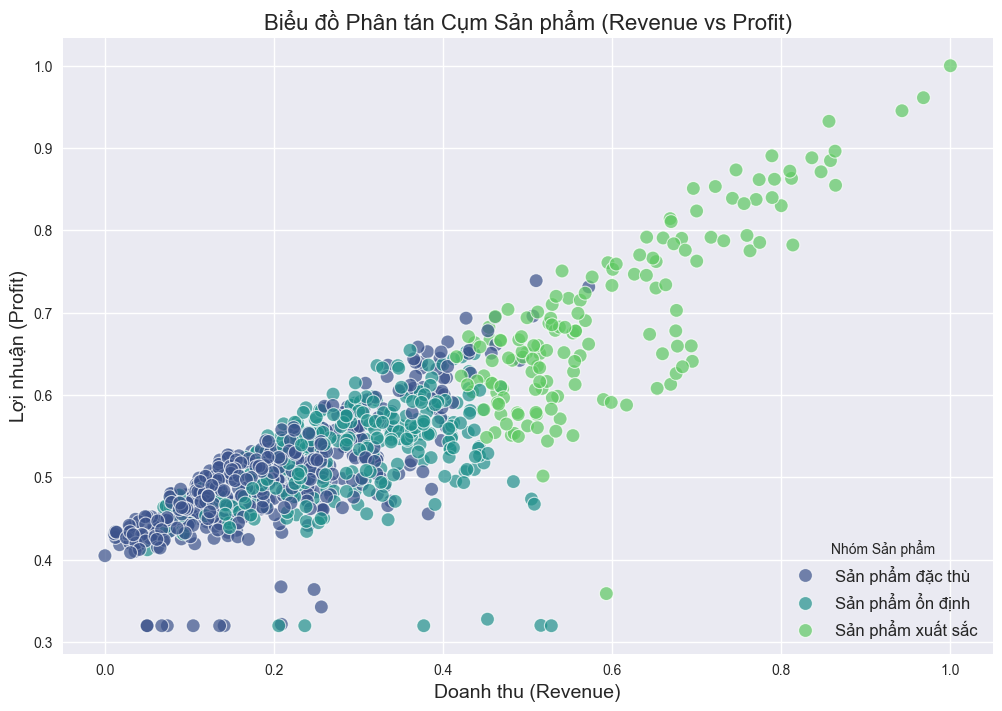

In [99]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x='revenue',
    y='profit',
    hue = 'cluster_name',
    data=df,
    palette='viridis',  
    s=100,              
    alpha=0.7           
)

plt.title('Biểu đồ Phân tán Cụm Sản phẩm (Revenue vs Profit)', fontsize=16)
plt.xlabel('Doanh thu (Revenue)', fontsize=14)
plt.ylabel('Lợi nhuận (Profit)', fontsize=14)
plt.legend(title='Nhóm Sản phẩm', loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

In [123]:
# 2) Phân khúc thị trường dựa trên revenue, profitMargin và quantityOrders của mỗi Country
features = ['Total_Revenue', 'Avg_AOV', 'Frequency']
# Giả sử dataset là DataFrame của bạn và đã có 'customerLifeTimeValue'
customer_df = df.groupby('customerNumber').agg(
    # 1. Total_Revenue (Monetary Value - Đã có trong CLV)
    Total_Revenue=('revenue', 'sum'),
    # 2. Frequency (Tần suất: Số lượng đơn hàng duy nhất)
    Frequency=('orderNumber', 'nunique'), 
    # 3. Avg_OrderValue (AOV: Giá trị Đơn hàng Trung bình)
    Avg_AOV=('revenue', 'mean')
).reset_index()

# Đặt customerNumber làm index
customer_df = customer_df.set_index('customerNumber')

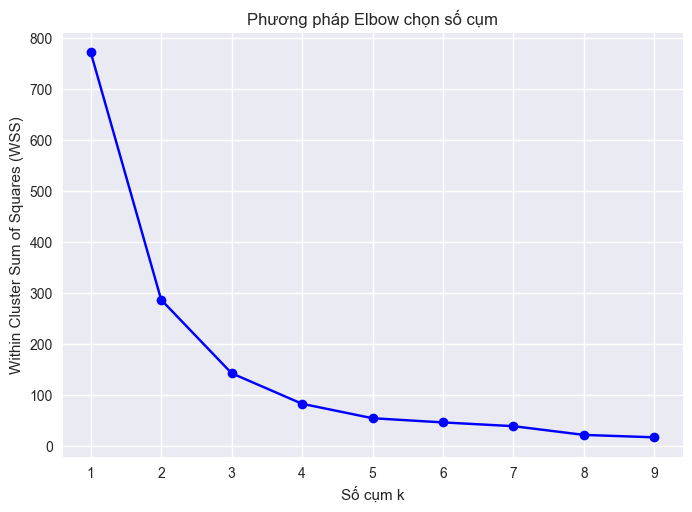

In [124]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(customer_df)
    inertia.append(model.inertia_)

plt.plot(range(1,10), inertia, 'bo-')
plt.xlabel('Số cụm k')
plt.ylabel('Within Cluster Sum of Squares (WSS)')
plt.title('Phương pháp Elbow chọn số cụm')
plt.show()

In [125]:
minmax_scaler = MinMaxScaler()
minmax_vars = ['Total_Revenue', 'Avg_AOV', 'Frequency']
customer_df[minmax_vars] = minmax_scaler.fit_transform(customer_df[minmax_vars])

In [126]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_clusters = kmeans.fit_predict(customer_df)

# 2. Gán kết quả vào cột mới 'customerCluster' trong customer_df
customer_df.loc[:, 'customerCluster'] = customer_clusters

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
centroids

,Total_Revenue,Avg_AOV,Frequency
0,0.202856,0.056478,0.420155
1,0.198230,0.031056,0.652344
2,0.900633,0.571429,0.537384


In [145]:
cluster_names = {
    0: 'Khách hàng giá trị thấp',
    1: 'Khách hàng trung thành', 
    2: 'Khách hàng VIP'
}
customer_df.loc[:, 'customer_name'] = customer_df['customerCluster'].map(cluster_names)


df = pd.merge(
    df,
    customer_df[['customer_name']].reset_index(), 
    on='customerNumber',           
    how='left'
)

customer_df


,revenue,profit,profitMargin,orderValue,customerLifeTimeValue,creditLimit,priceEach,customerNumber,orderNumber,buyPrice,...,product_Classic Cars,product_Motorcycles,product_Planes,product_Ships,product_Trains,product_Trucks and Buses,product_Vintage Cars,customer_name_x,customer_name_y,customer_name
0,0.211293,0.509966,0.910603,0.341073,0.112459,0.479686,0.323417,131,10107,0.305762,...,0,1,0,0,0,0,0,Khách hàng giá trị thấp,Khách hàng giá trị thấp,Khách hàng giá trị thấp
1,0.266633,0.546201,0.925482,0.250954,0.159380,0.323638,0.352152,353,10121,0.305762,...,0,1,0,0,0,0,0,Khách hàng trung thành,Khách hàng trung thành,Khách hàng trung thành
2,0.357291,0.602858,0.938822,0.359233,0.118807,0.263620,0.380947,250,10134,0.305762,...,0,1,0,0,0,0,0,Khách hàng trung thành,Khách hàng trung thành,Khách hàng trung thành
3,0.325247,0.543709,0.893830,0.793113,0.292354,0.367959,0.294622,205,10145,0.305762,...,0,1,0,0,0,0,0,Khách hàng giá trị thấp,Khách hàng giá trị thấp,Khách hàng giá trị thấp
4,0.386602,0.586510,0.910603,0.863053,0.468906,0.433980,0.323417,321,10159,0.305762,...,0,1,0,0,0,0,0,Khách hàng giá trị thấp,Khách hàng giá trị thấp,Khách hàng giá trị thấp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,0.142212,0.455063,0.861849,0.810410,0.906038,0.921053,0.116683,124,10142,0.161617,...,0,0,0,1,0,0,0,Khách hàng VIP,Khách hàng VIP,Khách hàng VIP
946,0.228646,0.504060,0.891842,0.616650,1.000000,1.000000,0.146199,141,10153,0.161617,...,0,0,0,1,0,0,0,Khách hàng VIP,Khách hàng VIP,Khách hàng VIP
947,0.174760,0.486467,0.897745,0.455123,0.152331,0.224377,0.152751,344,10177,0.161617,...,0,0,0,1,0,0,0,Khách hàng giá trị thấp,Khách hàng giá trị thấp,Khách hàng giá trị thấp
948,0.085338,0.438332,0.865451,0.711623,0.460977,0.385503,0.119929,320,10185,0.161617,...,0,0,0,1,0,0,0,Khách hàng giá trị thấp,Khách hàng giá trị thấp,Khách hàng giá trị thấp


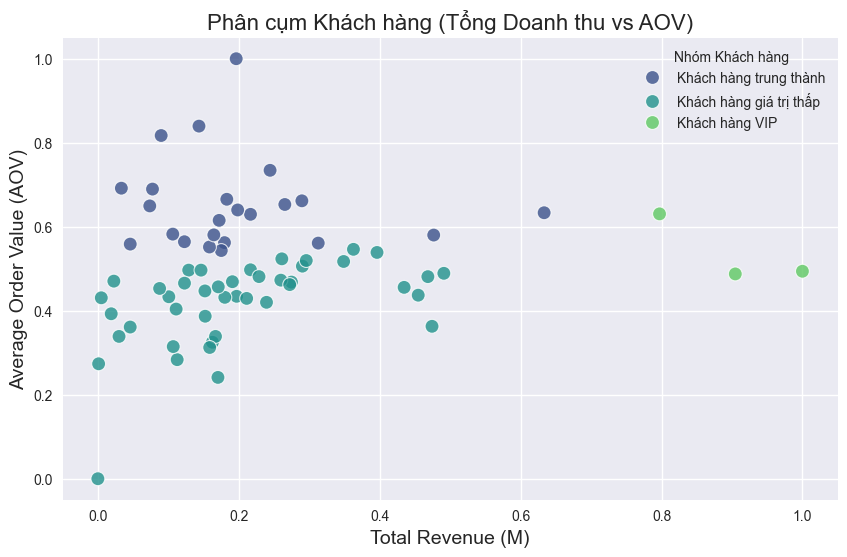

In [140]:
# Tên cột mới được giả định dựa trên kết quả Centroid
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Total_Revenue',  
    y='Avg_AOV',
    hue='customer_name', 
    data=customer_df,   
    palette='viridis', 
    s=100,            
    alpha=0.8         
)
plt.title('Phân cụm Khách hàng (Tổng Doanh thu vs AOV)', fontsize=16)
plt.xlabel('Total Revenue (M)', fontsize=14)
plt.ylabel('Average Order Value (AOV)', fontsize=14)
plt.legend(title='Nhóm Khách hàng', loc='upper right')
plt.grid(True)
plt.show()

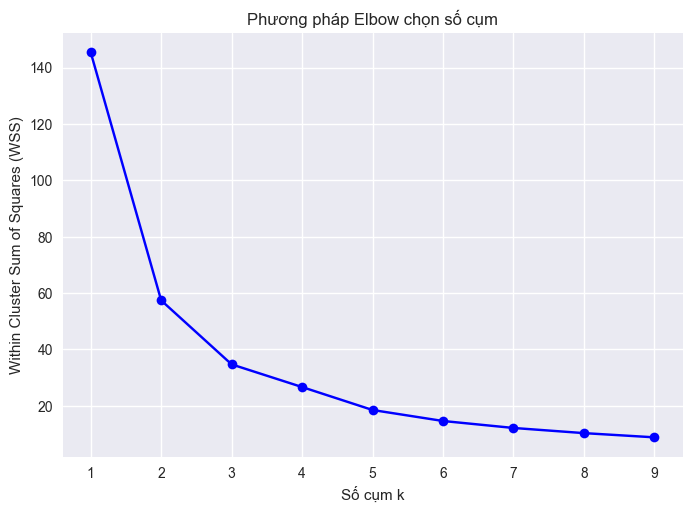

In [141]:
# 4.2. Mục tiêu #2: Phân cụm sản phẩm theo tỷ suất lợi nhuận và mức giá bán để hỗ trợ chiến lược định giá.
from sklearn.cluster import KMeans
features = ['profitMargin', 'MSRP', 'priceEach', 'buyPrice']

y = df[features].copy()
inertia = []
for k in range(1, 10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(y)
    inertia.append(model.inertia_)

plt.plot(range(1,10), inertia, 'bo-')
plt.xlabel('Số cụm k')
plt.ylabel('Within Cluster Sum of Squares (WSS)')
plt.title('Phương pháp Elbow chọn số cụm')
plt.show()

In [147]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(y)
df.loc[:, 'pricingCluster'] = cluster_labels

In [143]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns= features)
centroids

,profitMargin,MSRP,priceEach,buyPrice
0,0.934908,0.841963,0.805645,0.665327
1,0.886071,0.346005,0.339496,0.377905
2,0.924519,0.152356,0.154420,0.128017
3,0.892591,0.549379,0.548669,0.561852


In [148]:
cluster_names = {
    0: 'Sản phẩm Kim cương',
    1: 'Sản phẩm Vàng', 
    2: 'Sản phẩm Bạc',
    3: 'Sản phẩm Đồng'
}
df.loc[:,'pricing_cluster_name'] = df['pricingCluster'].map(cluster_names)

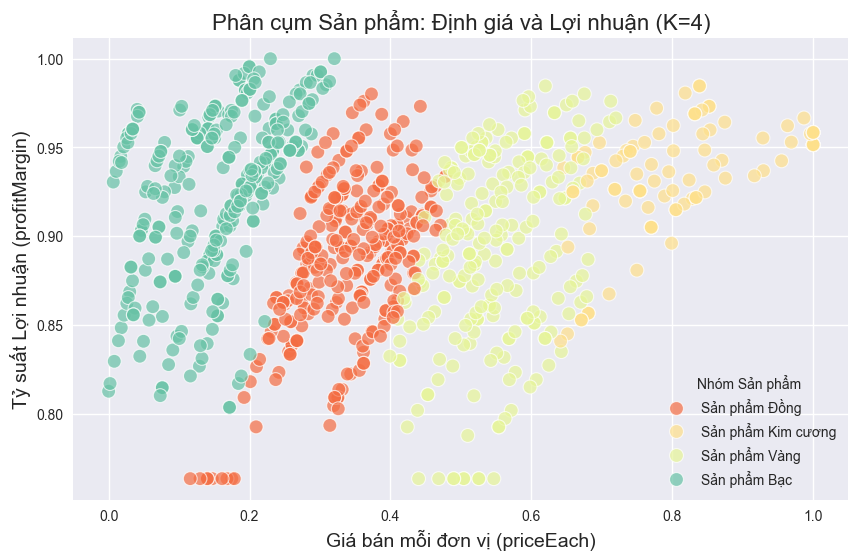

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='priceEach',
    y='profitMargin',
    hue='pricing_cluster_name',
    data=df, 
    palette='Spectral', # Chọn bảng màu tương phản
    s=100,
    alpha=0.7
)

plt.title('Phân cụm Sản phẩm: Định giá và Lợi nhuận (K=4)', fontsize=16)
plt.xlabel('Giá bán mỗi đơn vị (priceEach)', fontsize=14)
plt.ylabel('Tỷ suất Lợi nhuận (profitMargin)', fontsize=14)
plt.legend(title='Nhóm Sản phẩm', loc='lower right', fontsize=10)
plt.grid(True)
plt.show()

In [150]:
import pandas as pd
# Giả sử df là DataFrame gốc chứa cột 'pricingCluster' và các cột thô

# Tính trung bình MSRP và quantityInStock (Stock)
pricing_profile_quantitative = df.groupby('pricingCluster').agg({
    'MSRP': 'mean',
    'quantityInStock': 'mean' # Đại diện cho 'stock'
}).reset_index()

# In ra bảng kết quả để phân tích
print("## Hồ sơ Định lượng Sản phẩm theo Cụm Định giá ##")
print(pricing_profile_quantitative)

## Hồ sơ Định lượng Sản phẩm theo Cụm Định giá ##
   pricingCluster      MSRP  quantityInStock
0               0  0.841963         0.420392
1               1  0.549379         0.580634
2               2  0.152356         0.467244
3               3  0.346005         0.512033


C:\Users\ASUS\AppData\Local\Temp\ipykernel_15388\4284106516.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_15388\4284106516.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove() # Xóa chú giải vì 'hue' trùng với 'x'


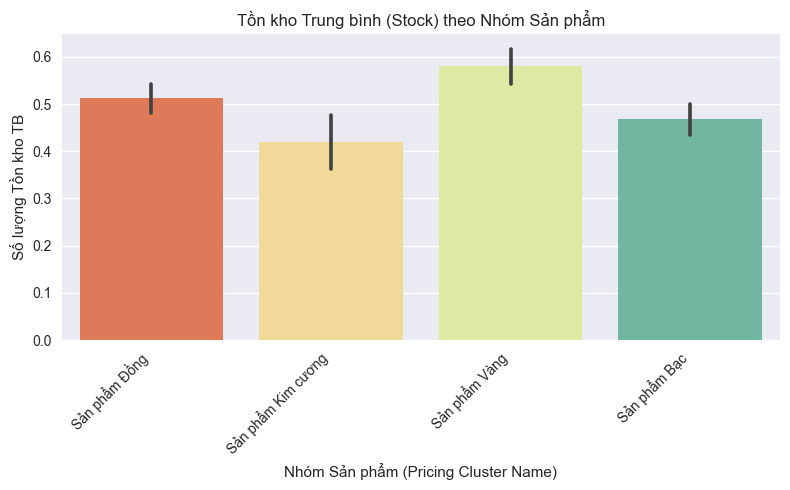

In [152]:


# Trực quan hóa Tồn kho TB theo Cụm
plt.figure(figsize=(8, 5))
# Đảm bảo dùng tên cột nhãn cụm đã gán tên: 'pricing_cluster_name'
sns.barplot(
    x='pricing_cluster_name', 
    y='quantityInStock', 
    data=df, 
    estimator=np.mean, 
    palette='Spectral'
)
plt.title('Tồn kho Trung bình (Stock) theo Nhóm Sản phẩm')
plt.xlabel('Nhóm Sản phẩm (Pricing Cluster Name)')
plt.ylabel('Số lượng Tồn kho TB')
plt.xticks(rotation=45, ha='right') # Xoay nhãn để dễ đọc
plt.legend().remove() # Xóa chú giải vì 'hue' trùng với 'x'
plt.tight_layout()
plt.show()

In [31]:
# 4.3. Mục tiêu #3: Phát hiện các combo sản phẩm (product) thường được mua kèm nhằm tối ưu chiến lược cross-selling.
from mlxtend.frequent_patterns import apriori, association_rules

df_orderdetails = dataset.copy()
basket = (df_orderdetails
          .groupby(['orderNumber', 'productCode'])['quantityOrdered']
          .count() 
          .unstack(fill_value=0))

basket_sets = basket.astype(bool)

frequent_itemsets_dm2 = apriori(basket_sets, min_support=0.08, use_colnames=True, max_len=3)
print("Total Frequent Itemsets:", frequent_itemsets_dm2.shape[0])

Total Frequent Itemsets: 165


In [32]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets_dm2, metric="confidence", min_threshold=1)

print("Association Rules:", rules.shape)
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

Association Rules: (256, 14)


,antecedents,consequents,support,confidence,lift
0,(S10_2016),(S10_4698),0.087379,1.0,11.444444
1,(S10_4698),(S10_2016),0.087379,1.0,11.444444
2,(S10_2016),(S18_2625),0.087379,1.0,11.444444
3,(S18_2625),(S10_2016),0.087379,1.0,11.444444
4,(S10_2016),(S24_1578),0.087379,1.0,11.444444
...,...,...,...,...,...
251,"(S24_3432, S24_3191)",(S24_2766),0.087379,1.0,11.444444
252,"(S24_2766, S24_3191)",(S24_3432),0.087379,1.0,11.444444
253,(S24_3432),"(S24_2766, S24_3191)",0.087379,1.0,11.444444
254,(S24_2766),"(S24_3432, S24_3191)",0.087379,1.0,11.444444


                   profit  buyPrice  priceEach  quantityOrdered
profit           1.000000  0.316114   0.726983         0.413890
buyPrice         0.316114  1.000000   0.811181        -0.017442
priceEach        0.726983  0.811181   1.000000         0.000415
quantityOrdered  0.413890 -0.017442   0.000415         1.000000


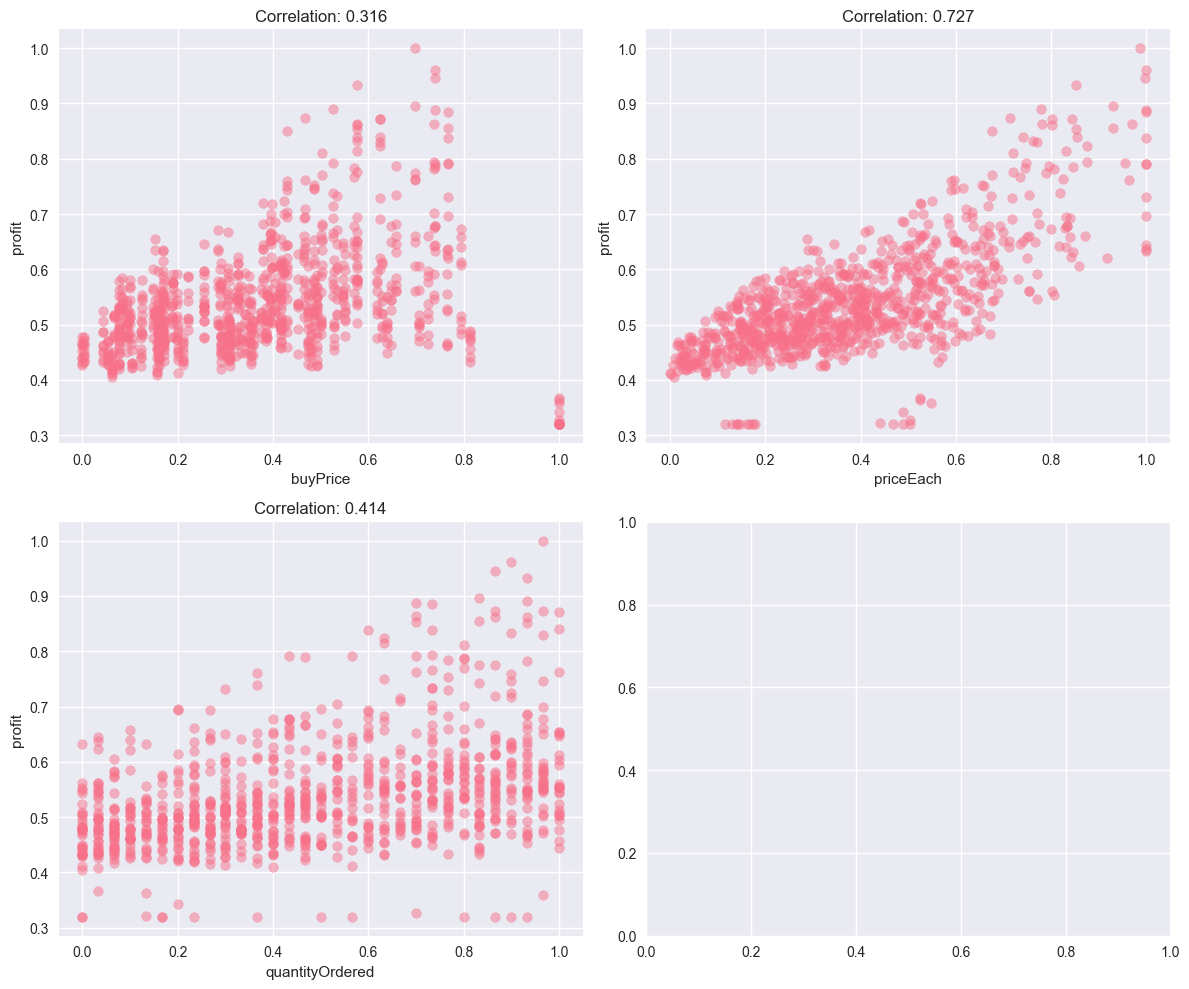

                            OLS Regression Results                            
Dep. Variable:                 profit   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.907
Method:                 Least Squares   F-statistic:                     3077.
Date:                Sat, 29 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:53:04   Log-Likelihood:                 1988.4
No. Observations:                 950   AIC:                            -3969.
Df Residuals:                     946   BIC:                            -3949.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.3749      0.003    1

In [153]:
# 4.4. Mục tiêu #4: Xây dựng mô hình dự đoán lợi nhuận dựa trên đặc trưng sản phẩm và đơn hàng.

df_fertilizer = dataset[['profit', 'buyPrice', 'priceEach', 'quantityOrdered']].copy()

# Hệ số tương quan giữa các biến
correlation_fertilize = df_fertilizer.corr()
print(correlation_fertilize)

# Vẽ scatter plot giữa profit và các biến quan trọng
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Profit vs buyPrice
axes[0,0].scatter(df_fertilizer['buyPrice'], df_fertilizer['profit'], alpha=0.5)
axes[0,0].set_xlabel('buyPrice')
axes[0,0].set_ylabel('profit')
axes[0,0].set_title(f'Correlation: {correlation_fertilize.loc["profit", "buyPrice"]:.3f}')

# Profit vs priceEach
axes[0,1].scatter(df_fertilizer['priceEach'], df_fertilizer['profit'], alpha=0.5)
axes[0,1].set_xlabel('priceEach')
axes[0,1].set_ylabel('profit')
axes[0,1].set_title(f'Correlation: {correlation_fertilize.loc["profit", "priceEach"]:.3f}')

# Profit vs quantityOrdered
axes[1,0].scatter(df_fertilizer['quantityOrdered'], df_fertilizer['profit'], alpha=0.5)
axes[1,0].set_xlabel('quantityOrdered')
axes[1,0].set_ylabel('profit')
axes[1,0].set_title(f'Correlation: {correlation_fertilize.loc["profit", "quantityOrdered"]:.3f}')

plt.tight_layout()
plt.show()

# 3. Modeling
X_fertilizer = df_fertilizer[['buyPrice', 'priceEach', 'quantityOrdered']]
y_fertilizer = df_fertilizer['profit']

# Add constant
X_fertilizer = sm.add_constant(X_fertilizer)

# Tạo mô hình hồi quy tuyến tính
model_fertilizer = sm.OLS(y_fertilizer, X_fertilizer)
results_fertilizer = model_fertilizer.fit()

print(results_fertilizer.summary())

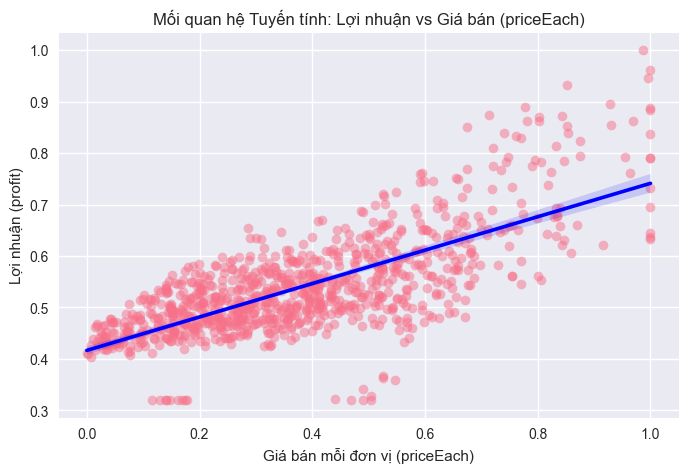

In [158]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
# Sử dụng regplot để thêm đường hồi quy
sns.regplot(x='priceEach', y='profit', data=df, scatter_kws={'alpha':0.5}, line_kws={"color": "blue"}) 
plt.title('Mối quan hệ Tuyến tính: Lợi nhuận vs Giá bán (priceEach)')
plt.xlabel('Giá bán mỗi đơn vị (priceEach)')
plt.ylabel('Lợi nhuận (profit)')
plt.grid(True)
plt.show()

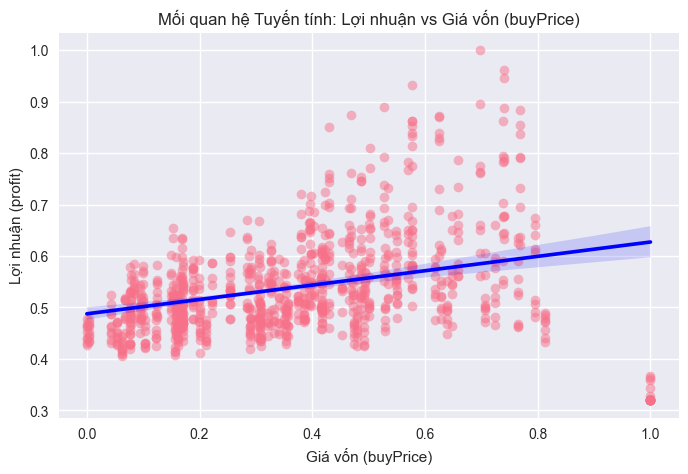

In [160]:
plt.figure(figsize=(8, 5))
sns.regplot(x='buyPrice', y='profit', data=df, scatter_kws={'alpha':0.5}, line_kws={"color": "blue"})
plt.title('Mối quan hệ Tuyến tính: Lợi nhuận vs Giá vốn (buyPrice)')
plt.xlabel('Giá vốn (buyPrice)')
plt.ylabel('Lợi nhuận (profit)')
plt.grid(True)
plt.show()

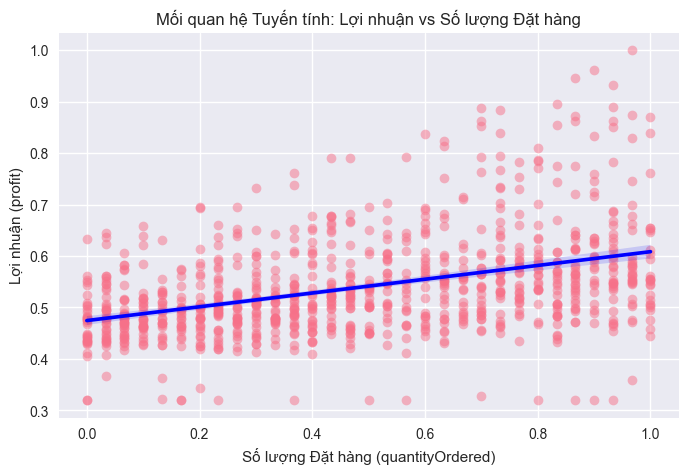

In [161]:
plt.figure(figsize=(8, 5))
sns.regplot(x='quantityOrdered', y='profit', data=df, scatter_kws={'alpha':0.5}, line_kws={"color": "blue"})
plt.title('Mối quan hệ Tuyến tính: Lợi nhuận vs Số lượng Đặt hàng')
plt.xlabel('Số lượng Đặt hàng (quantityOrdered)')
plt.ylabel('Lợi nhuận (profit)')
plt.grid(True)
plt.show()

In [162]:
# 4.5. Mục tiêu #5: Thực hiện kiểm định thống kê để xác định xem dòng sản phẩm (product line) có ảnh hưởng đáng kể đến doanh số hay không.
df_analysis = df.copy()

new_cols = {}
for col in df_analysis.columns:
    if ' ' in col and col.startswith('product_'):
        new_cols[col] = col.replace(' ', '_')

df_analysis.rename(columns=new_cols, inplace=True)
productLine_cols = [col for col in df_analysis.columns if col.startswith('product_')]

In [165]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# 1. Danh sách các cột biến giả (Dựa trên code trước của bạn)
# Ví dụ: ['product_Classic Cars', 'product_Motorcycles', ...]
# Cần đảm bảo list productLine_cols này chứa các cột trong df_analysis
productLine_cols = [col for col in df_analysis.columns if col.startswith('product_')]


def clean_col_name(col_name):
    """Sử dụng Q() trong patsy để xử lý tên cột có ký tự đặc biệt."""
    # Q() sẽ hoạt động cho cả khoảng trắng, gạch ngang, hoặc tên đã đổi
    return f"Q('{col_name}')"

# 2. Chọn cột tham chiếu (reference) và các cột dự đoán (predictors)
# Thường lấy cột cuối cùng làm reference để tránh đa cộng tuyến
reference_col = productLine_cols[-1] 
predictor_cols = [col for col in productLine_cols if col != reference_col]

# 3. LÀM SẠCH TÊN CỘT ĐỂ DÙNG TRONG CÔNG THỨC
cleaned_predictors = [clean_col_name(col) for col in predictor_cols]

# 4. Xây dựng công thức mô hình
formula = f"revenue ~ {' + '.join(cleaned_predictors)}"

print("\n--- Công thức Mô hình Hồi quy Tuyến tính Đã Sửa ---")
print(formula)

# 5. Chạy mô hình Hồi quy Tuyến tính (OLS)
model = ols(formula, data=df_analysis).fit()

# 6. Tạo Bảng ANOVA từ mô hình Hồi quy
anova_table = anova_lm(model, typ=2) 

print("\n--- Bảng Kết quả ANOVA (Kiểm định Ảnh hưởng Tổng thể) ---")
print(anova_table)

# 7. Phân tích p-value (Trả lời Câu hỏi 1)
# Lấy p-value của kiểm định F tổng thể (dòng chứa các biến dự đoán)
# Lấy tên cột dự đoán đầu tiên (đã được làm sạch) để tìm dòng trong anova_table
# anova_table.index[0] thường là dòng chứa tất cả các biến độc lập khi dùng typ=2
f_stat_pvalue = anova_table.iloc[0]['PR(>F)']


print("-" * 60)
if f_stat_pvalue < 0.05:
    print(f"p-value (Kiểm định F tổng thể) = {f_stat_pvalue:.4f} < 0.05. Bác bỏ H0.")
    print("Kết luận: CÓ sự khác biệt đáng kể về trung bình doanh thu giữa các dòng sản phẩm.")
else:
    print(f"p-value (Kiểm định F tổng thể) = {f_stat_pvalue:.4f} >= 0.05. Không bác bỏ H0.")
    print("Kết luận: KHÔNG có sự khác biệt đáng kể về trung bình doanh thu giữa các dòng sản phẩm.")


--- Công thức Mô hình Hồi quy Tuyến tính Đã Sửa ---
revenue ~ Q('product_Classic_Cars') + Q('product_Motorcycles') + Q('product_Planes') + Q('product_Ships') + Q('product_Trains') + Q('product_Trucks_and_Buses')

--- Bảng Kết quả ANOVA (Kiểm định Ảnh hưởng Tổng thể) ---
                                  sum_sq     df          F        PR(>F)
Q('product_Classic_Cars')       1.628742    1.0  56.765455  1.149336e-13
Q('product_Motorcycles')        0.100588    1.0   3.505715  6.146672e-02
Q('product_Planes')             0.043803    1.0   1.526641  2.169250e-01
Q('product_Ships')              0.011938    1.0   0.416067  5.190630e-01
Q('product_Trains')             0.029207    1.0   1.017922  3.132711e-01
Q('product_Trucks_and_Buses')   0.449122    1.0  15.652933  8.180020e-05
Residual                       27.057019  943.0        NaN           NaN
------------------------------------------------------------
p-value (Kiểm định F tổng thể) = 0.0000 < 0.05. Bác bỏ H0.
Kết luận: CÓ sự khác biệ

In [168]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Định nghĩa lại danh sách các cột OHE (dựa trên format của bạn)
# Ví dụ: ['product_Classic_Cars', 'product_Motorcycles', ...]
# Cần đảm bảo list này chứa tất cả các cột OHE
productLine_ohe_cols = [col for col in df_analysis.columns if col.startswith('product_')]

# 2. Thực hiện Reverse OHE: Lấy tên cột có giá trị 1 (TRUE) cho mỗi hàng
# .idxmax(axis=1) tìm tên cột có giá trị lớn nhất (là 1)
df_analysis['productLine_Original'] = df_analysis[productLine_ohe_cols].idxmax(axis=1)

# 3. Làm sạch tên: Xóa tiền tố 'product_' (và dấu gạch dưới)
df_analysis['productLine_Original'] = df_analysis['productLine_Original'].str.replace('product_', '', regex=False).str.replace('_', ' ', regex=False)

print("Đã khôi phục thành công cột 'productLine_Original'.")

# Thực hiện kiểm định Tukey's HSD
tukey_results = pairwise_tukeyhsd(endog=df_analysis['revenue'], 
                                  groups=df_analysis['productLine_Original'], 
                                  alpha=0.05)

print("\n## KẾT QUẢ KIỂM ĐỊNH TUKEY'S HSD (So sánh từng cặp) ##")
print(tukey_results)

Đã khôi phục thành công cột 'productLine_Original'.

## KẾT QUẢ KIỂM ĐỊNH TUKEY'S HSD (So sánh từng cặp) ##
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1           group2      meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------
    Classic Cars      Motorcycles  -0.0748 0.0009 -0.1288 -0.0208   True
    Classic Cars           Planes  -0.0859 0.0002 -0.1432 -0.0285   True
    Classic Cars            Ships  -0.0958 0.0007 -0.1637 -0.0279   True
    Classic Cars           Trains  -0.1461 0.0004 -0.2463 -0.0459   True
    Classic Cars Trucks and Buses  -0.0286 0.7776 -0.0871  0.0299  False
    Classic Cars     Vintage Cars  -0.1112    0.0 -0.1549 -0.0676   True
     Motorcycles           Planes  -0.0111 0.9991 -0.0796  0.0574  False
     Motorcycles            Ships   -0.021  0.985 -0.0985  0.0566  False
     Motorcycles           Trains  -0.0713  0.435 -0.1782  0.0357  False
     Motorcycles

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15388\1285953225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


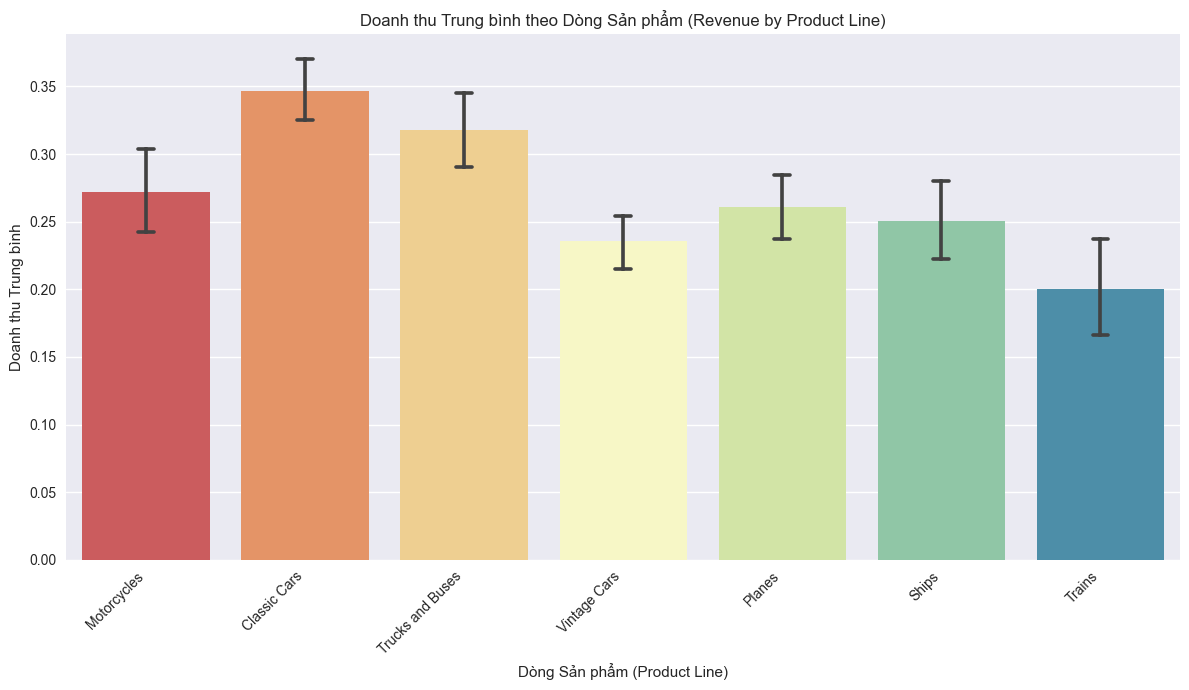

In [169]:
plt.figure(figsize=(12, 7))
sns.barplot(
    x='productLine_Original', 
    y='revenue', 
    data=df_analysis, 
    estimator=np.mean, 
    palette='Spectral', 
    capsize=0.1 # Thanh lỗi (Error Bar)
) 
plt.title('Doanh thu Trung bình theo Dòng Sản phẩm (Revenue by Product Line)')
plt.xlabel('Dòng Sản phẩm (Product Line)')
plt.ylabel('Doanh thu Trung bình')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()